<a href="https://colab.research.google.com/github/Aldiss1/MPPM_Aldi/blob/main/JS04/Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library & Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baca dataset
df = pd.read_csv('insurance.csv')

# Tampilkan 5 baris pertama data
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Preprocessing Data

In [2]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Encoding variabel biner (sex & smoker)
le = LabelEncoder()
df_encoded['sex'] = le.fit_transform(df_encoded['sex'])
df_encoded['smoker'] = le.fit_transform(df_encoded['smoker'])

# Encoding variabel dengan >2 kategori (region)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# Tampilkan hasil encoding
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


Pemisahan Fitur (X) dan Target (y) & Split Data

In [3]:
from sklearn.model_selection import train_test_split

# Memisahkan variabel bebas (X) dan target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test.shape}")

Ukuran X_train: (1070, 8)
Ukuran X_test : (268, 8)


Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

# Scaling untuk fitur X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scaling untuk target y (dibutuhkan khusus untuk SVR)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()


Pemodelan Multiple Linear Regression

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Inisialisasi dan melatih model Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Prediksi pada data uji
y_pred_lr = lr.predict(X_test_scaled)

# Evaluasi model Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Hasil Multiple Linear Regression ---")
print(f"MAE : {mae_lr:.2f}")
print(f"MSE : {mse_lr:.2f}")
print(f"R2  : {r2_lr:.4f}")

--- Hasil Multiple Linear Regression ---
MAE : 4181.19
MSE : 33596915.85
R2  : 0.7836


Pemodelan SVR dengan Hyperparameter Tuning

In [6]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# Definisi grid hyperparameter
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# Inisialisasi GridSearchCV untuk pencarian parameter terbaik
svr = SVR()
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_scaled)

# Prediksi menggunakan model SVR terbaik
best_svr = grid_search.best_estimator_
y_pred_svr_scaled = best_svr.predict(X_test_scaled)

# Mengembalikan hasil prediksi ke skala asli (inverse transform)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

# Evaluasi model SVR
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("--- Hasil Support Vector Regression (SVR) ---")
print(f"Parameter Terbaik : {grid_search.best_params_}")
print(f"MAE               : {mae_svr:.2f}")
print(f"MSE               : {mse_svr:.2f}")
print(f"R2                : {r2_svr:.4f}")

--- Hasil Support Vector Regression (SVR) ---
Parameter Terbaik : {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
MAE               : 2417.03
MSE               : 20345260.11
R2                : 0.8690


Visualisasi Data & Hasil

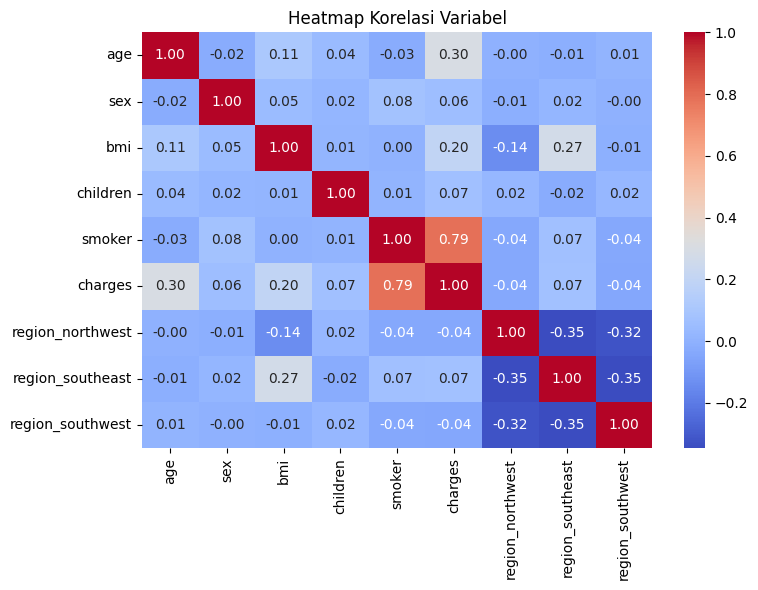

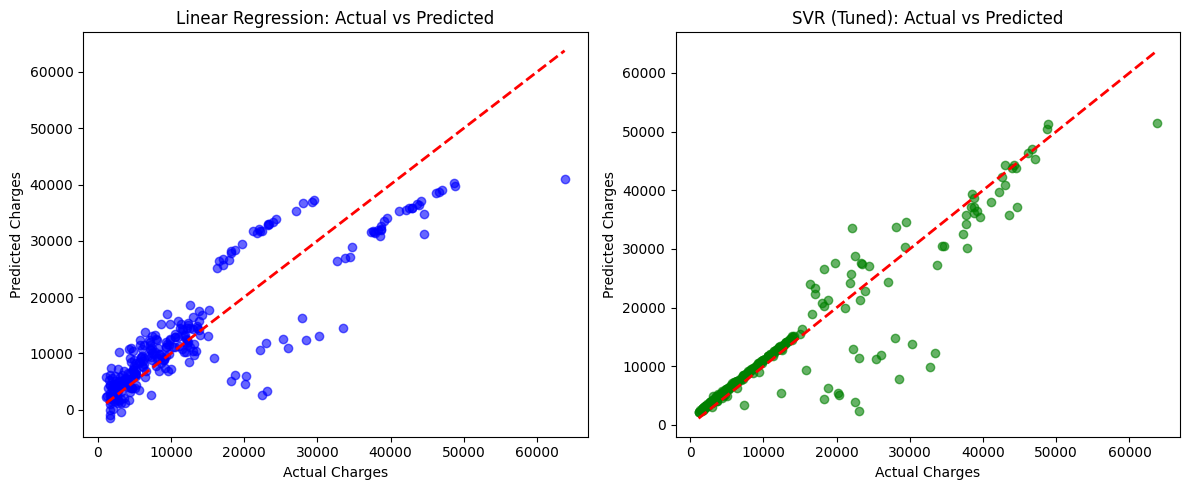

In [7]:
# 1. Visualisasi Heatmap Korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Variabel')
plt.tight_layout()
plt.show()

# 2. Visualisasi Prediksi vs Nilai Aktual
plt.figure(figsize=(12, 5))

# Plot Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')

# Plot SVR
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_svr, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('SVR (Tuned): Actual vs Predicted')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')

plt.tight_layout()
plt.show()